In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mplfinance as mpf
import scipy
import math
import pandas_ta as ta

In [2]:
def load_json_candles(fname):
    data = pd.read_json(fname)
    data.columns = ['timestamp', 'open', 'high', 'low', 'close', 'volume']
    data['timestamp'] = pd.to_datetime(data['timestamp'], unit='ms')
    data.set_index('timestamp', inplace=True)
    return data

def load_candles(exchange,base,quote,timeframe):
    fname = f'/media/mu6mula/Data/Crypto-Data-Feed/freq-user-data/data/{exchange}/{base}_{quote}-{timeframe}.json'
    return load_json_candles(fname)

def load_futures_candles(exchange,base,quote,timeframe):
    fname = f'/media/mu6mula/Data/Crypto-Data-Feed/freq-user-data/data/{exchange}/futures/{base}_{quote}_{quote}-{timeframe}-futures.json'
    return load_json_candles(fname)

def load_sp500_stock_candles(ticker):
    fname = f'/media/mu6mula/Data/Crypto-Data-Feed/sp500_data/{ticker}.csv'
    data = pd.read_csv(fname)
    data['Date'] = pd.to_datetime(data.Date)
    data.columns = [c.lower() for c in data.columns]
    data.set_index('date', inplace=True)
    return data

def load_russel2000_candles(ticker):
    fname = f'/media/mu6mula/Data/Crypto-Data-Feed/russell_2000_data/{ticker}.csv'
    data = pd.read_csv(fname)
    data['Date'] = pd.to_datetime(data.Date)
    data.columns = [c.lower() for c in data.columns]
    data.set_index('date', inplace=True)
    return data

In [24]:



def find_levels( 
        price: np.array, atr: float, # Log closing price, and log atr 
        first_w: float = 0.1, 
        atr_mult: float = 3.0, 
        prom_thresh: float = 0.1
):

    # Setup weights
    last_w = 1.0
    w_step = (last_w - first_w) / len(price)
    weights = first_w + np.arange(len(price)) * w_step
    weights[weights < 0] = 0.0

    # Get kernel of price. 
    kernal = scipy.stats.gaussian_kde(price, bw_method=atr*atr_mult, weights=weights)

    # Construct market profile
    min_v = np.min(price)
    max_v = np.max(price)
    step = (max_v - min_v) / 100
    price_range = np.arange(min_v, max_v, step)
    pdf = kernal(price_range) # Market profile

    # Find significant peaks in the market profile
    pdf_max = np.max(pdf)
    prom_min = pdf_max * prom_thresh

    peaks, props = scipy.signal.find_peaks(pdf, prominence=prom_min)
    levels = [] 
    for peak in peaks:
        levels.append(np.exp(price_range[peak]))

    return levels, peaks, props, price_range, pdf, weights




def support_resistance_levels(
        data: pd.DataFrame, lookback: int, 
        first_w: float = 0.01, atr_mult:float=3.0, prom_thresh:float =0.25
):

    # Get log average true range, 
    atr = ta.atr(np.log(data['high']), np.log(data['low']), np.log(data['close']), lookback)

    all_levels = [None] * len(data)
    for i in range(lookback, len(data)):
        i_start  = i - lookback
        vals = np.log(data.iloc[i_start+1: i+1]['close'].to_numpy())
        levels, peaks, props, price_range, pdf, weights= find_levels(vals, atr.iloc[i], first_w, atr_mult, prom_thresh)
        all_levels[i] = levels
        
    return all_levels

def sr_penetration_signal(data: pd.DataFrame, levels: list):
    signal = np.zeros(len(data))
    curr_sig = 0.0
    close_arr = data['close'].to_numpy()
    for i in range(1, len(data)):
        if levels[i] is None:
            continue

        last_c = close_arr[i - 1]
        curr_c = close_arr[i]

        
        for level in levels[i]:
            if curr_c > level and last_c <= level: # Close cross above line
                curr_sig = 1.0
            elif curr_c < level and last_c >= level: # Close cross below line
                curr_sig = -1.0

        signal[i] = curr_sig
    return signal

def get_trades_from_signal(data: pd.DataFrame, signal: np.array):
    long_trades = []
    short_trades = []

    close_arr = data['close'].to_numpy()
    last_sig = 0.0
    open_trade = None
    idx = data.index
    for i in range(len(data)):
        if signal[i] == 1.0 and last_sig != 1.0: # Long entry
            if open_trade is not None:
                open_trade[2] = idx[i] 
                open_trade[3] = close_arr[i]
                short_trades.append(open_trade)

            open_trade = [idx[i], close_arr[i], -1, np.nan]
        if signal[i] == -1.0  and last_sig != -1.0: # Short entry
            if open_trade is not None:
                open_trade[2] = idx[i] 
                open_trade[3] = close_arr[i]
                long_trades.append(open_trade)

            open_trade = [idx[i], close_arr[i], -1, np.nan]

        last_sig = signal[i]

    long_trades = pd.DataFrame(long_trades, columns=['entry_time', 'entry_price', 'exit_time', 'exit_price'])
    short_trades = pd.DataFrame(short_trades, columns=['entry_time', 'entry_price', 'exit_time', 'exit_price'])

    long_trades['percent'] = (long_trades['exit_price'] - long_trades['entry_price']) / long_trades['entry_price'] 
    short_trades['percent'] = -1 * (short_trades['exit_price'] - short_trades['entry_price']) / short_trades['entry_price']
    long_trades = long_trades.set_index('entry_time')
    short_trades = short_trades.set_index('entry_time')
    return long_trades, short_trades 





In [25]:

data = load_candles('binance','ADA','USDT','1h')#.iloc[-5000:]
# data = load_futures_candles('bybit','ALGO','USDT','1h')['2020-03':'2025']
# data = data['2021-11-01':].copy()
nhours = 28
data = data.resample(f'{nhours}h').agg( {'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'})
# short_long = [-1,1]

In [26]:

levels = support_resistance_levels(data, 365, first_w=1.0, atr_mult=3.0)

In [27]:

# plt.style.use('dark_background') 

data['sr_signal'] = sr_penetration_signal(data, levels)
data['log_ret'] = np.log(data['close']).diff()#.shift(-1)
data['sr_return'] = data['sr_signal'].shift() * data['log_ret']

long_trades, short_trades = get_trades_from_signal(data, data['sr_signal'].to_numpy())



In [28]:
long_trades

,entry_price,exit_time,exit_price,percent
entry_time,,,,
2019-10-29 00:00:00,0.04335,2019-10-30 04:00:00,0.04142,-0.044521
2019-11-03 20:00:00,0.04320,2019-11-07 08:00:00,0.04257,-0.014583
2019-11-09 16:00:00,0.04347,2019-11-13 04:00:00,0.04248,-0.022774
2019-11-14 08:00:00,0.04338,2019-11-19 00:00:00,0.04191,-0.033887
2020-01-16 08:00:00,0.04264,2020-03-08 20:00:00,0.04156,-0.025328
2020-04-23 08:00:00,0.04279,2020-10-29 08:00:00,0.09266,1.165459
2020-11-05 08:00:00,0.10612,2021-05-22 16:00:00,1.16940,10.019600
2021-05-23 20:00:00,1.55000,2021-06-20 20:00:00,1.17400,-0.242581
2021-06-23 04:00:00,1.33750,2021-06-25 12:00:00,1.23750,-0.074766


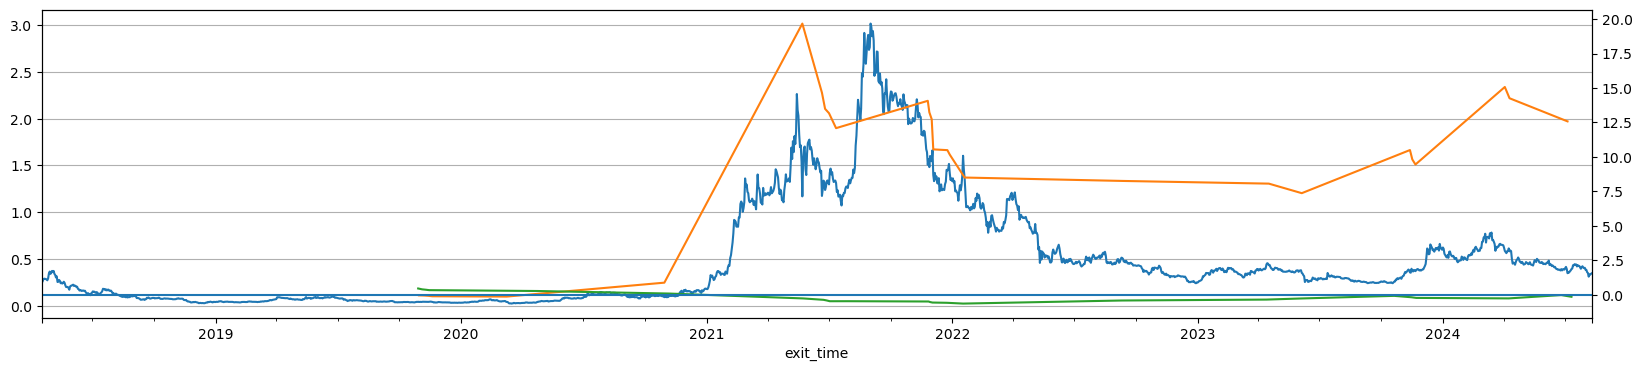

In [29]:
ax1 = data.close.plot(figsize=(20,4))
# 
ax2=(long_trades.set_index('exit_time')['percent']+1).cumprod().subtract(1).plot(ax=ax1,secondary_y=True)
(short_trades.set_index('exit_time')['percent']+1).cumprod().subtract(1).plot(ax=ax1,secondary_y=True)
ax1.grid(axis='y')
ax2.axhline()

<Axes: xlabel='entry_time'>

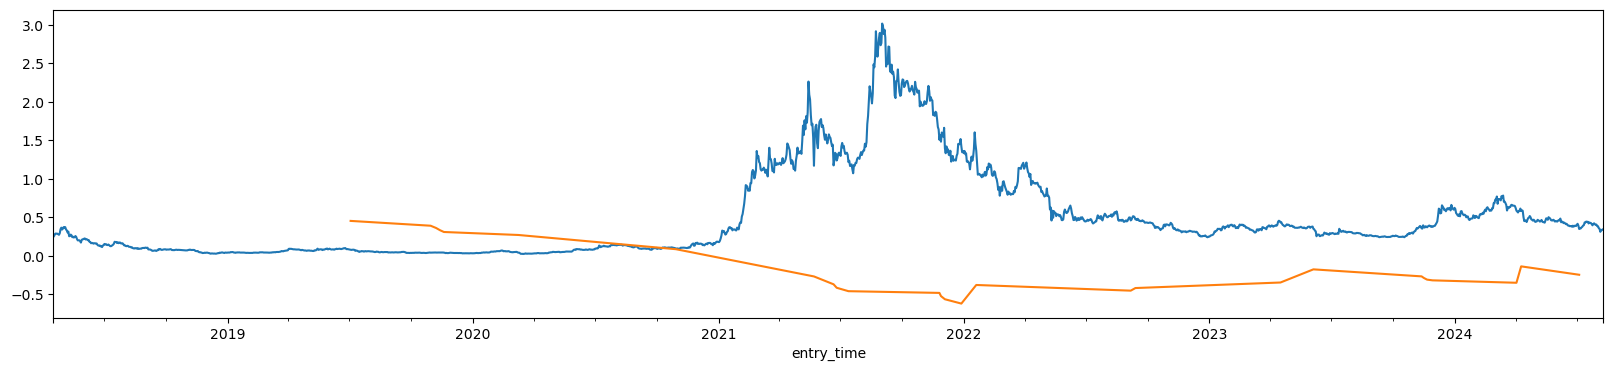

In [15]:
ax1 = data.close.plot(figsize=(20,4))
(short_trades['percent']+1).cumprod().subtract(1).plot(ax=ax1)